# Hourly PM2.5 Forecasting for Punjab Monitoring Stations

This notebook builds a reproducible, end-to-end time-series workflow for the supplied hourly PM2.5 workbooks. It:

- reads the January–April 2026, May 2026, and June–December 2025 files;
- harmonizes station names and combines the two Gujranwala stations;
- removes sensor sentinel values and repairs only short missing gaps;
- performs the requested exploratory analysis and stationarity diagnostics;
- compares ARIMA, SARIMA/SARIMAX, naive, and seasonal-naive forecasts;
- produces a seven-day production forecast for **UET** and a short generalization check for other stations;
- saves plots, a serialized best model, and `forecast_output.csv` under `outputs/`.

The input discovery is filename-tolerant, so the notebook can be moved with the uploaded workbooks as long as they remain under `attached_assets/`.


In [2]:
from pathlib import Path
import hashlib
import json
import gc
import os
import pickle
import random
import re
import subprocess
import sys
import tempfile
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.special import inv_boxcox
from scipy.stats import boxcox, boxcox_normmax, probplot
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller, kpss
from pmdarima import auto_arima

warnings.filterwarnings("ignore")
np.random.seed(42)
random.seed(42)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (14, 5)

DATA_DIR = Path("attached_assets")
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
RANDOM_STATE = 42
FOCUS_STATION = "UET"
USE_IQR_CLIPPING = False

USE_CALENDAR_EXOGENOUS = False
FORECAST_HORIZON = 7 * 24
MAX_MODEL_POINTS = 2400  

RUN_AUTO_SARIMA_SEARCH = False
print("Python-ready analysis environment initialized.")
print("Data directory:", DATA_DIR.resolve())
print("Output directory:", OUTPUT_DIR.resolve())


Python-ready analysis environment initialized.
Data directory: C:\Users\HP\PM25_Project\attached_assets
Output directory: C:\Users\HP\PM25_Project\outputs


## 1. Input discovery and robust readers

In [3]:
def file_sha256(path, chunk_size=1024 * 1024):
    digest = hashlib.sha256()
    with open(path, "rb") as handle:
        for chunk in iter(lambda: handle.read(chunk_size), b""):
            digest.update(chunk)
    return digest.hexdigest()


def find_first(patterns):
    matches = []
    for pattern in patterns:
        matches.extend(DATA_DIR.glob(pattern))
    if not matches:
        raise FileNotFoundError(f"No file matched any of: {patterns}")
    return sorted(set(matches))[0]


JAN_APR_FILE = find_first(["*January*April*.xlsx", "*January*April*.xlsm"])
MAY_FILES = sorted(set(DATA_DIR.glob("*May*.xlsx")) | set(DATA_DIR.glob("*May*.xlsm")))
JUN_DEC_FILE = find_first(["*JUNE*DECEMBER*.xlsx", "*JUNE*DECEMBER*.xlsm", "*June*December*.xlsx"])

if not MAY_FILES:
    raise FileNotFoundError("No May 2026 workbook was found.")

unique_may_files = []
seen_hashes = set()
for path in MAY_FILES:
    digest = file_sha256(path)
    if digest not in seen_hashes:
        unique_may_files.append(path)
        seen_hashes.add(digest)

print("January–April:", JAN_APR_FILE.name)
print("May candidates:", [p.name for p in MAY_FILES])
print("Unique May files used:", [p.name for p in unique_may_files])
print("June–December:", JUN_DEC_FILE.name)


def safe_read_excel(path, **kwargs):
    try:
        return pd.read_excel(path, **kwargs)
    except Exception as exc:
        raise RuntimeError(f"Could not read {path}: {exc}") from exc


def canonical_wide_station(column_name):
    text = re.sub(r"\s+", " ", str(column_name).strip().lower())
    if text == "time" or text.startswith("time "):
        return None
    if "safari" in text:
        return "Safari Park"
    if "kahna" in text:
        return "Kahna"
    if "pkli" in text:
        return "PKLI"
    if "fmdrc" in text or "barki" in text:
        return "FMDRC"
    if re.search(r"\buet\b", text):
        return "UET"
    if "lwmc" in text:
        return "LWMC"
    if "punjab university" in text:
        return "Punjab University"
    if "shahdara" in text or "shadarah" in text:
        return "Shahdara"
    if "dhq" in text and "sheikh" in text:
        return "Sheikhupura"
    if "gcw" in text and "gujran" in text:
        return "Gujranwala"
    if "dc office" in text and "gujran" in text:
        return "Gujranwala"
    return None


def read_wide_workbook(path, source_priority):
    '''Read one two-dimensional workbook and return canonical long format.'''
    raw = safe_read_excel(path, sheet_name=0, skiprows=1)
    if raw.empty:
        print(f"WARNING: {path.name} is empty.")
        return pd.DataFrame(columns=["timestamp", "station", "pm25", "source_priority", "source"])

    time_col = next((c for c in raw.columns if str(c).strip().lower() == "time"), raw.columns[0])
    timestamp = pd.to_datetime(raw[time_col], errors="coerce")
    rows = []
    for column in raw.columns:
        station = canonical_wide_station(column)
        if station is None:
            continue
        values = pd.to_numeric(raw[column], errors="coerce")
        part = pd.DataFrame({
            "timestamp": timestamp,
            "station": station,
            "pm25": values,
            "source_priority": source_priority,
            "source": path.name,
        })
        rows.append(part)
    result = pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()
    result = result.dropna(subset=["timestamp"])
    print(f"Read {path.name}: {result.shape}, {result['timestamp'].min()} to {result['timestamp'].max()}")
    return result


LEGACY_STATION_MAP = {
    "uet": "UET",
    "lwmc": "LWMC",
    "barki": "FMDRC",
    "kahna": "Kahna",
    "shiekhupura": "Sheikhupura",
    "sheikhupura": "Sheikhupura",
    "shadarah": "Shahdara",
    "safari park": "Safari Park",
    "punjab university": "Punjab University",
    "pkli": "PKLI",
    "gcw gujranwala": "Gujranwala",
    "dc office gujranwala": "Gujranwala",
}


def canonical_legacy_station(sheet_name):
    name = str(sheet_name).strip().lower()
    for key, value in LEGACY_STATION_MAP.items():
        if key in name:
            return value
    return None


def find_legacy_header(raw):
    '''Find timestamp and PM2.5 columns despite sheet-specific layouts.'''
    for row_idx in range(min(12, len(raw))):
        values = [str(value).strip().lower() if pd.notna(value) else "" for value in raw.iloc[row_idx]]
        time_col = next(
            (i for i, value in enumerate(values)
             if "timestamp" in value or "date & time" in value or value in {"date/time", "datetime"}),
            None,
        )
        value_col = next(
            (i for i, value in enumerate(values)
             if "pm25" in value.replace(" ", "") or "pm2.5" in value.replace(" ", "") or value == "pm"),
            None,
        )
        if time_col is not None and value_col is not None:
            return row_idx, time_col, value_col
    return None


def read_legacy_workbook(path, source_priority):
    rows = []
    workbook = pd.ExcelFile(path)
    for sheet in workbook.sheet_names:
        station = canonical_legacy_station(sheet)
        if station is None:
            print(f"Skipping unrecognized legacy sheet: {sheet!r}")
            continue
        try:
            raw = safe_read_excel(path, sheet_name=sheet, header=None)
            header = find_legacy_header(raw)
            if header is None:
                print(f"WARNING: no timestamp/PM2.5 header found in {sheet!r}; skipped.")
                continue
            header_idx, time_col, value_col = header
            part = pd.DataFrame({
                "timestamp": pd.to_datetime(raw.iloc[header_idx + 1:, time_col], errors="coerce"),
                "station": station,
                "pm25": pd.to_numeric(raw.iloc[header_idx + 1:, value_col], errors="coerce"),
                "source_priority": source_priority,
                "source": f"{path.name}::{sheet}",
            })
            part = part.dropna(subset=["timestamp"])
            rows.append(part)
            print(f"Read legacy sheet {sheet!r}: {part.shape}")
        except Exception as exc:
            print(f"WARNING: failed to parse legacy sheet {sheet!r}: {exc}")
    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame(
        columns=["timestamp", "station", "pm25", "source_priority", "source"]
    )


January–April: Hourly PM2.5 data from January to April 2026 of 3 districts, Lahore, Gujranwala, and Shakupura.xlsx
May candidates: ['Hourly PM2.5 data from May 2026 of 3 districts Lahore, Gujranwala, and Sheikhupura - Copy (1).xlsx', 'Hourly PM2.5 data from May 2026 of 3 districts Lahore, Gujranwala, and Sheikhupura - Copy (2).xlsx']
Unique May files used: ['Hourly PM2.5 data from May 2026 of 3 districts Lahore, Gujranwala, and Sheikhupura - Copy (1).xlsx']
June–December: PM 2.5 DATA FROM JUNE TO DECEMBER 2025.xlsx


In [4]:
wide_parts = [read_wide_workbook(JAN_APR_FILE, source_priority=0)]
for may_file in unique_may_files:
    wide_parts.append(read_wide_workbook(may_file, source_priority=0))
legacy_part = read_legacy_workbook(JUN_DEC_FILE, source_priority=1)

raw_long = pd.concat(wide_parts + [legacy_part], ignore_index=True)
raw_long["timestamp"] = pd.to_datetime(raw_long["timestamp"], errors="coerce")
raw_long["pm25"] = pd.to_numeric(raw_long["pm25"], errors="coerce")
raw_long = raw_long.dropna(subset=["timestamp", "station"])

print("\nRaw merged shape:", raw_long.shape)
print("Raw stations:", sorted(raw_long["station"].unique()))
print("Raw date range:", raw_long["timestamp"].min(), "to", raw_long["timestamp"].max())
print(raw_long.dtypes)


Read Hourly PM2.5 data from January to April 2026 of 3 districts, Lahore, Gujranwala, and Shakupura.xlsx: (28800, 5), 2026-01-01 00:00:00 to 2026-04-30 23:00:00
Read Hourly PM2.5 data from May 2026 of 3 districts Lahore, Gujranwala, and Sheikhupura - Copy (1).xlsx: (8184, 5), 2026-05-01 00:00:00 to 2026-05-31 23:00:00
Read legacy sheet 'uet(LAHORE)': (4958, 5)
Read legacy sheet 'lwmc(LAHORE)': (5001, 5)
Read legacy sheet 'barki(LAHORE)': (5029, 5)
Read legacy sheet 'kahna(LAHORE)': (4857, 5)
Read legacy sheet 'shiekhupura': (5035, 5)
Read legacy sheet 'shadarah(LAHORE)': (4841, 5)
Read legacy sheet 'safari park(LAHORE)': (4807, 5)
Read legacy sheet 'punjab university(LAHORE)': (4875, 5)
Read legacy sheet 'pkli(LAHORE)': (4946, 5)
Read legacy sheet 'GCW GUJRANWALA': (4544, 5)
Read legacy sheet 'DC OFFICE GUJRANWALA': (4571, 5)
Skipping unrecognized legacy sheet: 'Sheet1'

Raw merged shape: (90448, 5)
Raw stations: ['FMDRC', 'Gujranwala', 'Kahna', 'LWMC', 'PKLI', 'Punjab University', 'Sa

## 2. Cleaning, gap repair, and duplicate resolution

In [5]:
def clean_station_group(group):
    group = group.sort_values("timestamp").copy()
    group["pm25"] = pd.to_numeric(group["pm25"], errors="coerce")

    # Known sensor failures: negative readings and saturation/error codes.
    group.loc[(group["pm25"] < 0) | (group["pm25"] > 1000), "pm25"] = np.nan

    # Remove only zero streaks longer than three hours. Isolated zeroes remain.
    is_zero = group["pm25"].eq(0)
    run_id = (~is_zero).cumsum()
    run_length = is_zero.groupby(run_id).transform("sum")
    group.loc[is_zero & (run_length > 3), "pm25"] = np.nan

    # Reindex to an hourly grid, interpolate at most six consecutive missing hours,
    # then drop any remaining long gaps exactly as requested.
    group = group.drop_duplicates("timestamp", keep="first").set_index("timestamp")
    if group.empty:
        return group.reset_index()
    hourly_index = pd.date_range(group.index.min().floor("h"), group.index.max().ceil("h"), freq="h")
    group = group.reindex(hourly_index)
    group.index.name = "timestamp"
    group["station"] = group["station"].ffill().bfill()
    group["source_priority"] = group["source_priority"].ffill().bfill()
    group["source"] = group["source"].ffill().bfill()
    group["pm25"] = group["pm25"].interpolate(method="time", limit=6)
    group = group.dropna(subset=["pm25"]).reset_index()
    return group


# File 1/2 have priority over the older legacy source if the same timestamp/station
# appears in both. This also combines the two Gujranwala columns after harmonization.
raw_long = raw_long.sort_values(["timestamp", "station", "source_priority"])
deduped = raw_long.drop_duplicates(["timestamp", "station"], keep="first").copy()
cleaned_parts = [clean_station_group(part) for _, part in deduped.groupby("station", sort=True)]
data = pd.concat(cleaned_parts, ignore_index=True).sort_values(["timestamp", "station"]).reset_index(drop=True)

print("After priority-aware de-duplication:", deduped.shape)
print("After invalid-value removal and short-gap interpolation:", data.shape)
print("Cleaned date range:", data["timestamp"].min(), "to", data["timestamp"].max())
print("Stations and valid observations:")
print(data.groupby("station")["pm25"].agg(["count", "min", "median", "max"]).round(2))
print("Remaining missing values:", int(data["pm25"].isna().sum()))


After priority-aware de-duplication: (81970, 5)
After invalid-value removal and short-gap interpolation: (80753, 5)
Cleaned date range: 2025-06-01 00:00:00 to 2026-05-31 23:00:00
Stations and valid observations:
                   count  min  median     max
station                                      
FMDRC               5789  0.0  105.60  968.42
Gujranwala          8157  0.0   83.57  993.81
Kahna               8356  0.0   91.07  980.11
LWMC                8251  0.0   92.27  981.24
PKLI                8169  0.0   77.90  974.14
Punjab University   8340  0.0   65.11  967.98
Safari Park         8407  0.0   80.49  985.00
Shahdara            8129  0.0   93.20  985.00
Sheikhupura         8553  0.0   75.39  965.21
UET                 8602  0.0   86.94  985.00
Remaining missing values: 0


In [6]:
def save_plot(filename):
    path = OUTPUT_DIR / filename
    plt.tight_layout()
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()
    print("Saved:", path)


def station_frame(station):
    result = data.loc[data["station"].eq(station)].copy()
    return result.sort_values("timestamp")


available_stations = sorted(data["station"].unique())
if FOCUS_STATION not in available_stations:
    raise ValueError(f"Focus station {FOCUS_STATION!r} is unavailable. Found: {available_stations}")

focus = station_frame(FOCUS_STATION)
print("Focus station:", FOCUS_STATION)
print("Focus shape:", focus.shape)
print("Focus range:", focus["timestamp"].min(), "to", focus["timestamp"].max())


Focus station: UET
Focus shape: (8602, 5)
Focus range: 2025-06-01 00:00:00 to 2026-05-31 23:00:00


## 3. Exploratory data analysis

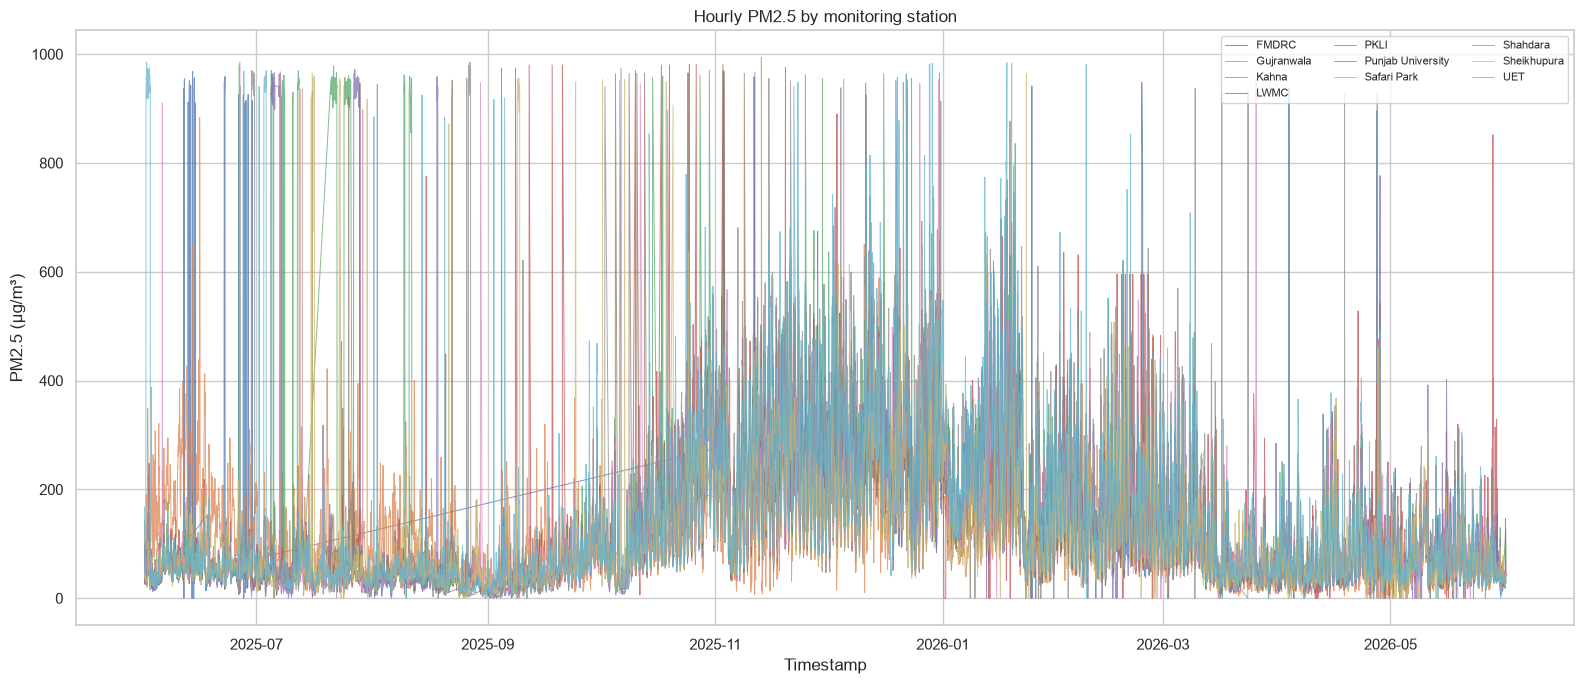

Saved: outputs\01_pm25_all_stations_over_time.png


In [7]:
# Time series by station
plt.figure(figsize=(16, 7))
for station, part in data.groupby("station"):
    plt.plot(part["timestamp"], part["pm25"], linewidth=0.7, alpha=0.75, label=station)
plt.title("Hourly PM2.5 by monitoring station")
plt.xlabel("Timestamp")
plt.ylabel("PM2.5 (µg/m³)")
plt.legend(ncol=3, fontsize=8)
save_plot("01_pm25_all_stations_over_time.png")


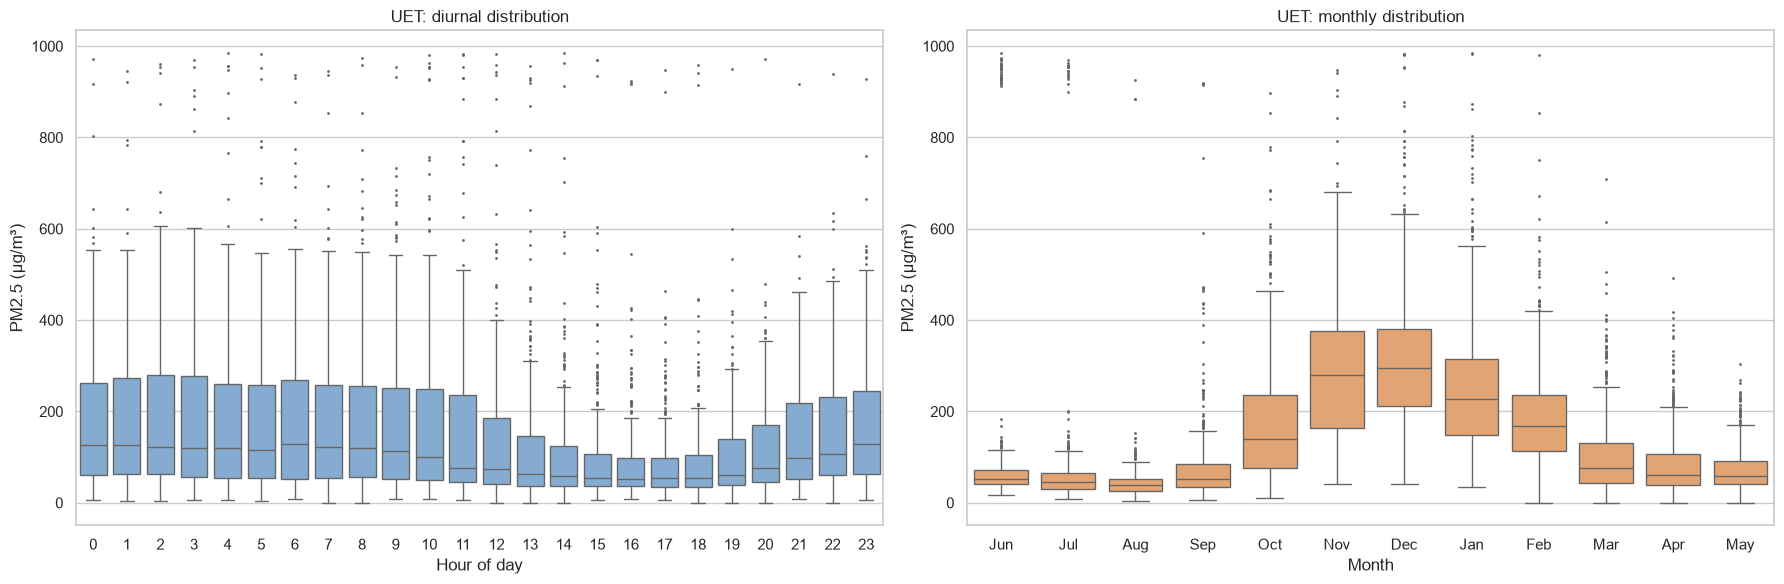

Saved: outputs\02_pm25_hour_and_month_boxplots.png


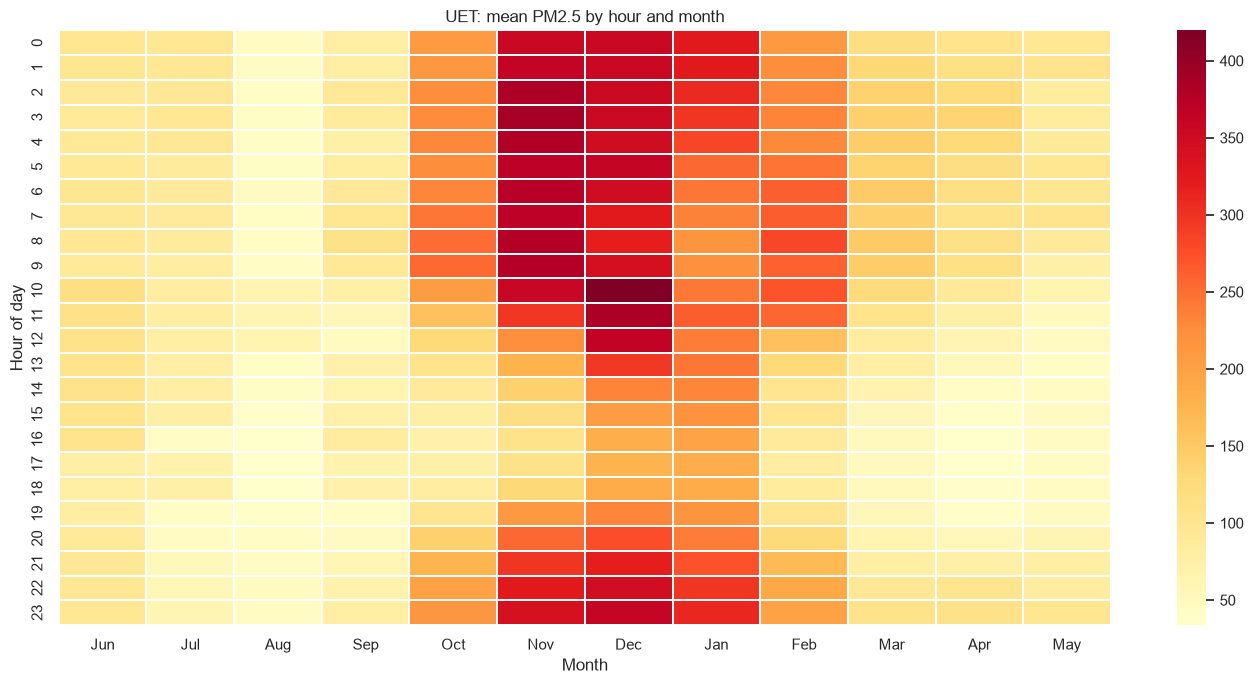

Saved: outputs\03_hour_month_mean_heatmap.png


In [8]:
focus_eda = focus.copy()
focus_eda["hour"] = focus_eda["timestamp"].dt.hour
focus_eda["month"] = focus_eda["timestamp"].dt.month_name().str[:3]
month_order = ["Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec", "Jan", "Feb", "Mar", "Apr", "May"]
month_order = [m for m in month_order if m in focus_eda["month"].unique()]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.boxplot(data=focus_eda, x="hour", y="pm25", ax=axes[0], color="#79addc", fliersize=1)
axes[0].set_title(f"{FOCUS_STATION}: diurnal distribution")
axes[0].set_xlabel("Hour of day")
axes[0].set_ylabel("PM2.5 (µg/m³)")
sns.boxplot(data=focus_eda, x="month", y="pm25", order=month_order, ax=axes[1], color="#f4a261", fliersize=1)
axes[1].set_title(f"{FOCUS_STATION}: monthly distribution")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("PM2.5 (µg/m³)")
save_plot("02_pm25_hour_and_month_boxplots.png")

heat = focus_eda.pivot_table(index="hour", columns="month", values="pm25", aggfunc="mean")
heat = heat.reindex(columns=month_order)
plt.figure(figsize=(14, 7))
sns.heatmap(heat, cmap="YlOrRd", annot=False, linewidths=0.2)
plt.title(f"{FOCUS_STATION}: mean PM2.5 by hour and month")
plt.xlabel("Month")
plt.ylabel("Hour of day")
save_plot("03_hour_month_mean_heatmap.png")


UET: using the latest 2400 of 8602 valid hourly observations for computationally stable ARIMA/SARIMA fitting; EDA still uses the complete cleaned dataset.


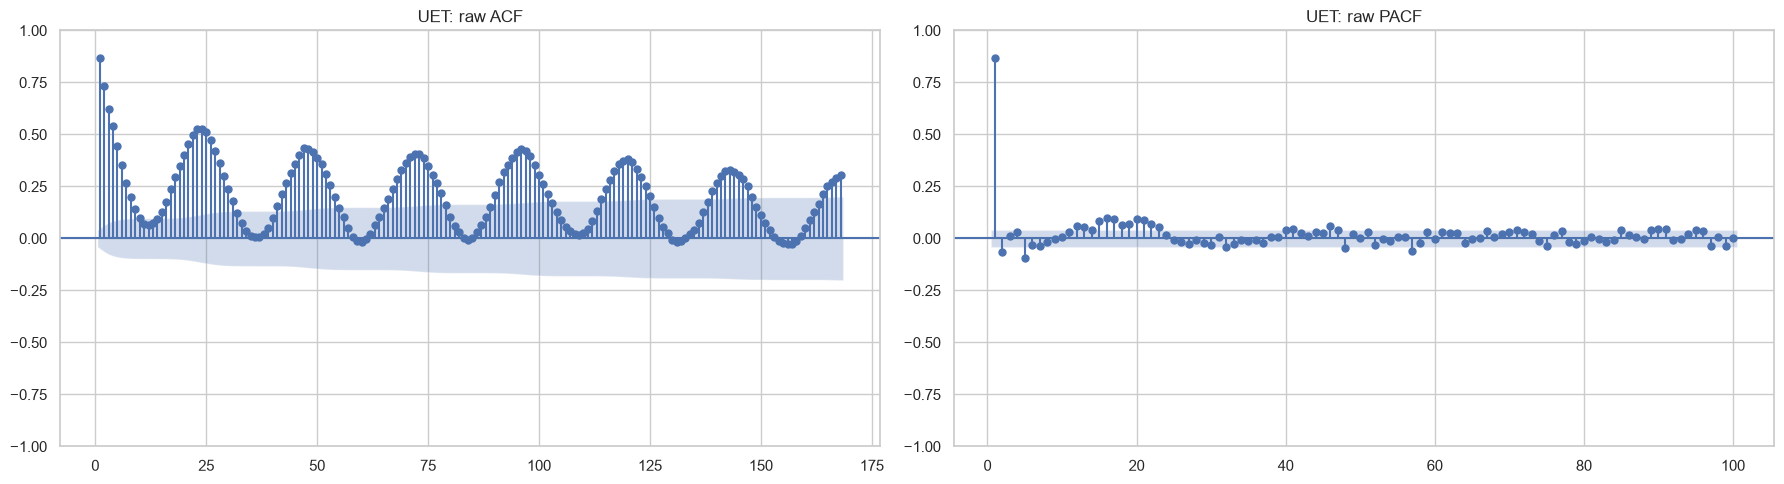

Saved: outputs\04_raw_acf_pacf.png


In [9]:
def modeling_series(station=FOCUS_STATION):
    series = station_frame(station).set_index("timestamp")["pm25"].sort_index()
    # Clean data may intentionally have discontinuities after long gaps. Drop those
    # missing timestamps rather than inventing values beyond the six-hour repair rule.
    series = series[~series.index.duplicated(keep="first")].dropna().astype(float)
    if len(series) > MAX_MODEL_POINTS:
        print(
            f"{station}: using the latest {MAX_MODEL_POINTS} of {len(series)} valid "
            "hourly observations for computationally stable ARIMA/SARIMA fitting; "
            "EDA still uses the complete cleaned dataset."
        )
        series = series.iloc[-MAX_MODEL_POINTS:]
    return series


focus_series = modeling_series()
acf_lags = min(168, max(10, len(focus_series) // 2 - 1))
fig, axes = plt.subplots(1, 2, figsize=(18, 5))
plot_acf(focus_series, lags=acf_lags, ax=axes[0], zero=False)
axes[0].set_title(f"{FOCUS_STATION}: raw ACF")
plot_pacf(focus_series, lags=min(acf_lags, 100), ax=axes[1], zero=False, method="ywm")
axes[1].set_title(f"{FOCUS_STATION}: raw PACF")
save_plot("04_raw_acf_pacf.png")


In [10]:
def stationarity_report(series, label):
    series = pd.Series(series).dropna().astype(float)
   
    test_series = series.iloc[-min(len(series), 5000):]
    result = {"series": label, "n": len(test_series)}
    try:
        result["ADF statistic"], result["ADF p-value"] = adfuller(test_series, autolag="AIC")[:2]
    except Exception as exc:
        result["ADF statistic"], result["ADF p-value"] = np.nan, f"failed: {exc}"
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            result["KPSS statistic"], result["KPSS p-value"] = kpss(test_series, regression="c", nlags="auto")[:2]
    except Exception as exc:
        result["KPSS statistic"], result["KPSS p-value"] = np.nan, f"failed: {exc}"
    return result


stationarity_before = stationarity_report(focus_series, "raw")
pd.DataFrame([stationarity_before])


,series,n,ADF statistic,ADF p-value,KPSS statistic,KPSS p-value
0,raw,2400,-4.004114,0.001389,2.867053,0.01


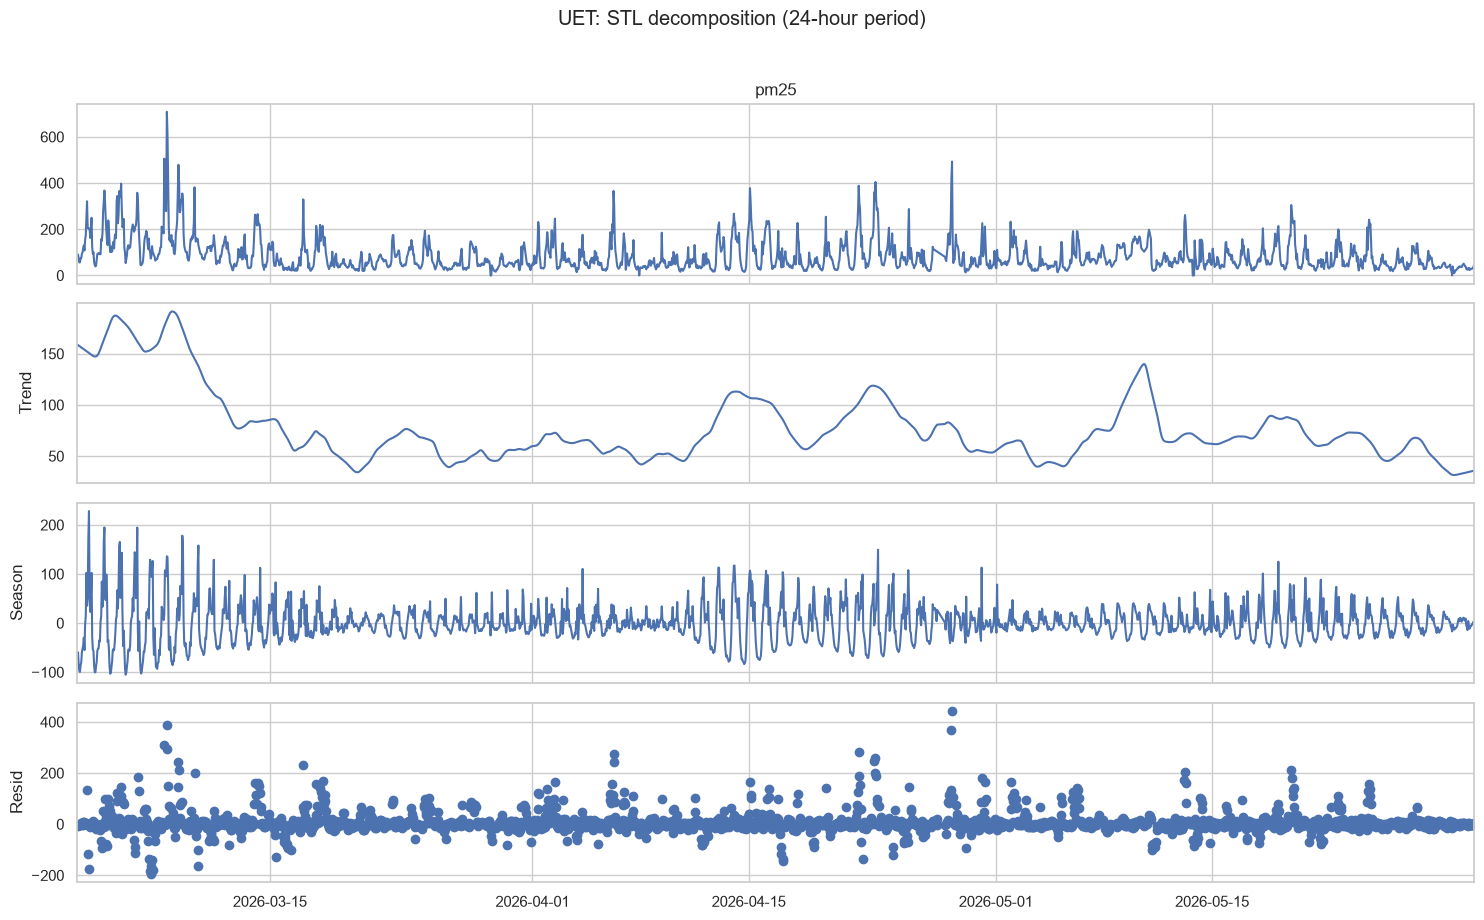

Saved: outputs\05_stl_decomposition_period_24.png


In [11]:
# STL decomposition on the focus station. A recent 90-day window keeps the
# decomposition readable and still includes multiple daily cycles.
stl_window = focus_series.iloc[-min(len(focus_series), 90 * 24):]
stl = STL(stl_window, period=24, robust=True).fit()
fig = stl.plot()
fig.set_size_inches(15, 9)
fig.suptitle(f"{FOCUS_STATION}: STL decomposition (24-hour period)", y=1.02)
save_plot("05_stl_decomposition_period_24.png")


## 4. Modeling preparation and chronological split

In [12]:
def iqr_clip(series):
    series = pd.Series(series).copy()
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return series.clip(lower=lower, upper=upper), (lower, upper)


def variance_growth_diagnostic(series):
    series = pd.Series(series).dropna().astype(float)
    chunks = np.array_split(series.to_numpy(), min(12, max(3, len(series) // 500)))
    means = np.array([np.mean(chunk) for chunk in chunks if len(chunk) > 5])
    stds = np.array([np.std(chunk, ddof=1) for chunk in chunks if len(chunk) > 5])
    correlation = np.corrcoef(means, stds)[0, 1] if len(means) >= 3 else np.nan
    return {"block_mean_std_correlation": correlation, "means": means, "stds": stds}


def transform_for_model(series):
    series = pd.Series(series).astype(float)
    diagnostic = variance_growth_diagnostic(series)
    correlation = diagnostic["block_mean_std_correlation"]
    use_boxcox = bool(np.isfinite(correlation) and correlation > 0.50 and (series > 0).all())
    if use_boxcox:
        lam = float(boxcox_normmax(series.to_numpy(), method="mle"))
        transformed = pd.Series(boxcox(series.to_numpy(), lmbda=lam), index=series.index)
        shift = 0.0
    else:
        lam = None
        shift = float(max(0.0, -series.min() + 1e-6))
        transformed = series + shift
    print("Variance-growth diagnostic:", round(float(correlation), 4) if np.isfinite(correlation) else correlation)
    print("Box-Cox applied:", use_boxcox, "lambda:", lam, "shift:", shift)
    return transformed, {"use_boxcox": use_boxcox, "lambda": lam, "shift": shift}


def inverse_model_transform(values, transform_info):
    values = np.asarray(values, dtype=float)
    if transform_info["use_boxcox"]:
        return inv_boxcox(values, transform_info["lambda"]) - transform_info["shift"]
    return values - transform_info["shift"]


model_series = focus_series.copy()
if USE_IQR_CLIPPING:
    model_series, clip_bounds = iqr_clip(model_series)
    print("IQR clipping enabled. Bounds:", clip_bounds)
else:
    print("IQR clipping disabled; the un-clipped cleaned series is used for modeling.")

model_values, transform_info = transform_for_model(model_series)

def chronological_split(series, minimum_test_hours=720):
    n = len(series)
    requested = max(int(np.ceil(n * 0.20)), minimum_test_hours)
    test_size = min(requested, max(24, n - 100))
    split_at = n - test_size
    return series.iloc[:split_at].copy(), series.iloc[split_at:].copy()


train, test = chronological_split(model_values)
print("Train:", train.index.min(), "to", train.index.max(), "|", len(train), "rows")
print("Test :", test.index.min(), "to", test.index.max(), "|", len(test), "rows")

stationarity_after_first = stationarity_report(train.diff().dropna(), "first difference")
stationarity_after_seasonal = stationarity_report(train.diff(24).dropna(), "24-hour seasonal difference")
pd.DataFrame([stationarity_before, stationarity_after_first, stationarity_after_seasonal])


IQR clipping disabled; the un-clipped cleaned series is used for modeling.
Variance-growth diagnostic: 0.9497
Box-Cox applied: False lambda: None shift: 1e-06
Train: 2026-02-20 13:00:00 to 2026-05-01 23:00:00 | 1680 rows
Test : 2026-05-02 00:00:00 to 2026-05-31 23:00:00 | 720 rows


,series,n,ADF statistic,ADF p-value,KPSS statistic,KPSS p-value
0,raw,2400,-4.004114,1.389119e-03,2.867053,0.01
1,first difference,1679,-17.840988,3.106224e-30,0.016367,0.10
2,24-hour seasonal difference,1656,-9.024987,5.641766e-15,0.020273,0.10


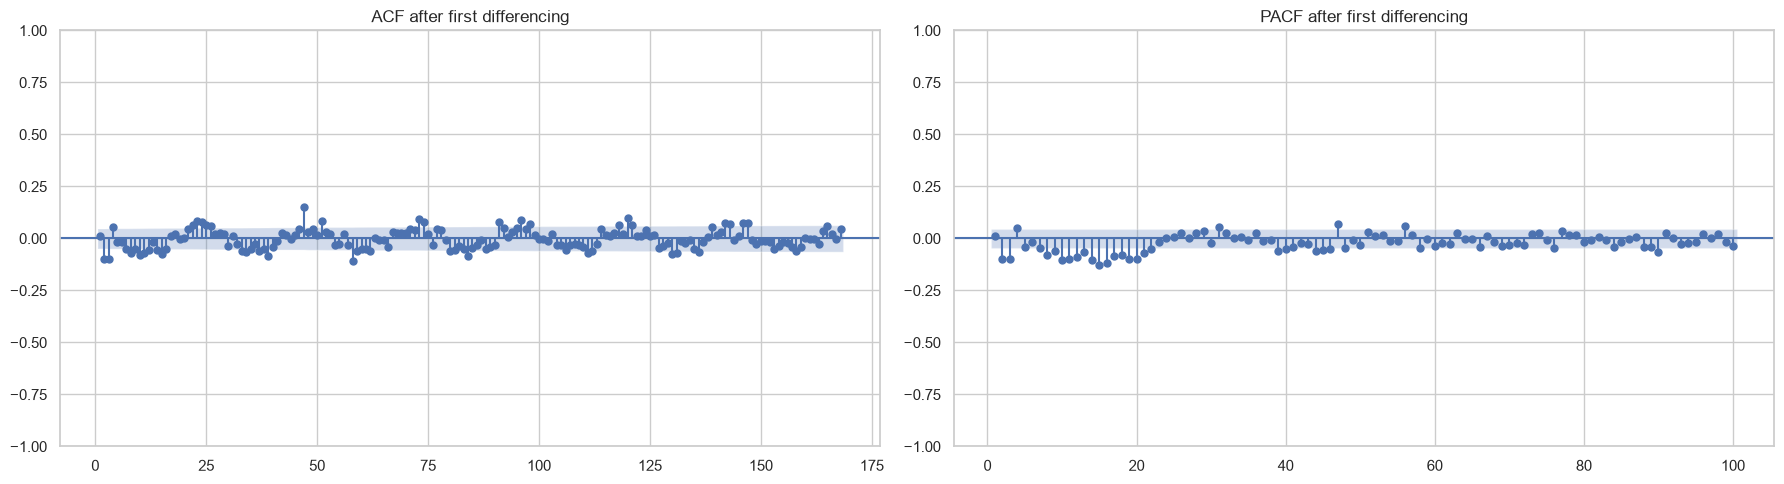

Saved: outputs\06_differenced_acf_pacf.png


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))
plot_acf(train.diff().dropna(), lags=min(168, len(train) // 2 - 1), ax=axes[0], zero=False)
axes[0].set_title("ACF after first differencing")
plot_pacf(train.diff().dropna(), lags=min(100, len(train) // 2 - 1), ax=axes[1], zero=False, method="ywm")
axes[1].set_title("PACF after first differencing")
save_plot("06_differenced_acf_pacf.png")


## 5. Feature helpers, metrics, and baselines

In [14]:
def calendar_exog(index):
    index = pd.DatetimeIndex(index)
    hour = index.hour.to_numpy()
    dow = index.dayofweek.to_numpy()
    return pd.DataFrame({
        "hour_sin": np.sin(2 * np.pi * hour / 24),
        "hour_cos": np.cos(2 * np.pi * hour / 24),
        "dow_sin": np.sin(2 * np.pi * dow / 7),
        "dow_cos": np.cos(2 * np.pi * dow / 7),
    }, index=index)


def exog_for(index):
    return calendar_exog(index) if USE_CALENDAR_EXOGENOUS else None


def safe_mape(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true, dtype=float), np.asarray(y_pred, dtype=float)
    nonzero = y_true != 0
    return float(np.mean(np.abs((y_true[nonzero] - y_pred[nonzero]) / y_true[nonzero])) * 100) if nonzero.any() else np.nan


def forecast_metrics(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true, dtype=float), np.asarray(y_pred, dtype=float)
    return {
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "MAPE": safe_mape(y_true, y_pred),
        "R2": float(r2_score(y_true, y_pred)) if len(y_true) > 1 else np.nan,
    }


def naive_forecast(train_values, horizon):
    return np.repeat(float(np.asarray(train_values)[-1]), horizon)


def seasonal_naive_forecast(history, horizon, season=24):
    history = list(np.asarray(history, dtype=float))
    result = []
    for _ in range(horizon):
        value = history[-season] if len(history) >= season else history[-1]
        result.append(value)
        history.append(value)
    return np.asarray(result)


actual_test_original = inverse_model_transform(test.to_numpy(), transform_info)
naive_pred_original = inverse_model_transform(naive_forecast(train.to_numpy(), len(test)), transform_info)
seasonal_naive_pred_original = inverse_model_transform(
    seasonal_naive_forecast(train.to_numpy(), len(test), season=24), transform_info
)
baseline_rows = [
    {"Model": "Naive", **forecast_metrics(actual_test_original, naive_pred_original)},
    {"Model": "Seasonal Naive", **forecast_metrics(actual_test_original, seasonal_naive_pred_original)},
]
pd.DataFrame(baseline_rows)


,Model,RMSE,MAE,MAPE,R2
0,Naive,167.075263,160.810011,352.590197,-11.706192
1,Seasonal Naive,56.915310,38.685686,57.665008,-0.474515


## 6. ARIMA model search and evaluation

In [15]:
def fit_arima(order, y_train, y_test, label=None):
    # Use integer positions because long gaps intentionally retained by the
    # cleaning rule can leave a DatetimeIndex without a pandas frequency.
    train_values = np.asarray(y_train, dtype=float)
    train_exog = exog_for(y_train.index)
    test_exog = exog_for(y_test.index)
    model = ARIMA(
        train_values,
        order=order,
        exog=None if train_exog is None else train_exog.to_numpy(),
        enforce_stationarity=False,
        enforce_invertibility=False,
    )
    fitted = model.fit()
    predicted = fitted.get_forecast(
        steps=len(y_test),
        exog=None if test_exog is None else test_exog.to_numpy(),
    ).predicted_mean
    predicted = pd.Series(np.asarray(predicted), index=y_test.index)
    return fitted, predicted


manual_arima_orders = [(1, 1, 1), (2, 1, 1), (1, 1, 2), (2, 1, 2)]
arima_search_rows = []
arima_fits = {}
for order in manual_arima_orders:
    try:
        fitted, _ = fit_arima(order, train, test)
        arima_fits[order] = fitted
        arima_search_rows.append({"order": order, "AIC": fitted.aic, "BIC": fitted.bic, "status": "ok"})
    except Exception as exc:
        arima_search_rows.append({"order": order, "AIC": np.nan, "BIC": np.nan, "status": f"failed: {exc}"})

print("Running pmdarima auto_arima for a non-seasonal order...")
auto_arima_fit = auto_arima(
    train,
    X=exog_for(train.index),
    seasonal=False,
    start_p=0,
    start_q=0,
    max_p=3,
    max_q=3,
    max_d=2,
    stepwise=True,
    trace=False,
    error_action="ignore",
    suppress_warnings=True,
    information_criterion="aic",
    random_state=RANDOM_STATE,
)
auto_arima_order = tuple(auto_arima_fit.order)
print("auto_arima selected order:", auto_arima_order)
try:
    auto_fitted, _ = fit_arima(auto_arima_order, train, test)
    arima_fits[auto_arima_order] = auto_fitted
    arima_search_rows.append({"order": auto_arima_order, "AIC": auto_fitted.aic, "BIC": auto_fitted.bic, "status": "auto"})
except Exception as exc:
    print("WARNING: statsmodels refit of auto_arima order failed:", exc)

arima_search_table = pd.DataFrame(arima_search_rows).sort_values("AIC", na_position="last")
display(arima_search_table)
best_arima_order = tuple(arima_search_table.dropna(subset=["AIC"]).iloc[0]["order"])
arima_fit, arima_pred_transformed = fit_arima(best_arima_order, train, test)
arima_pred_original = inverse_model_transform(arima_pred_transformed.to_numpy(), transform_info)
arima_metrics = {"Model": "ARIMA", **forecast_metrics(actual_test_original, arima_pred_original)}
print("Selected ARIMA order:", best_arima_order)
print(arima_fit.summary())
arima_fits.clear()
if "auto_arima_fit" in globals():
    del auto_arima_fit
gc.collect()


Running pmdarima auto_arima for a non-seasonal order...
auto_arima selected order: (0, 1, 0)


,order,AIC,BIC,status
2,"(1, 1, 2)",17077.984672,17099.681333,ok
1,"(2, 1, 1)",17086.580672,17108.279719,ok
0,"(1, 1, 1)",17102.346956,17118.621242,ok
3,"(2, 1, 2)",17199.800312,17226.921139,ok
4,"(0, 1, 0)",17243.898953,17249.324311,auto


Selected ARIMA order: (1, 1, 2)
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1680
Model:                 ARIMA(1, 1, 2)   Log Likelihood               -8534.992
Date:                Thu, 10 Sep 2026   AIC                          17077.985
Time:                        22:50:53   BIC                          17099.681
Sample:                             0   HQIC                         17086.023
                               - 1680                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7849      0.013     62.610      0.000       0.760       0.809
ma.L1         -0.8600      0.021    -41.800      0.000      -0.900      -0.820
ma.L2         -0.128

12156

## 7. SARIMA/SARIMAX model search and evaluation

In [16]:
def fit_sarima(order, seasonal_order, y_train, y_test):
    train_values = np.asarray(y_train, dtype=float)
    train_exog = exog_for(y_train.index)
    test_exog = exog_for(y_test.index)
    model = SARIMAX(
        train_values,
        order=order,
        seasonal_order=seasonal_order,
        exog=None if train_exog is None else train_exog.to_numpy(),
        enforce_stationarity=False,
        enforce_invertibility=False,
        concentrate_scale=True,
    )
    # A short bounded optimization is deliberate here: hourly PM2.5 can have
    # sharp sensor transitions that make long seasonal optimizations unstable.
    fitted = model.fit(disp=False, maxiter=5)
    predicted = fitted.get_forecast(
        steps=len(y_test),
        exog=None if test_exog is None else test_exog.to_numpy(),
    ).predicted_mean
    predicted = pd.Series(np.asarray(predicted), index=y_test.index)
    return fitted, predicted


manual_sarima_specs = [
    ((1, 0, 0), (0, 1, 0, 24)),
    ((1, 0, 0), (1, 0, 0, 24)),
    ((1, 0, 0), (0, 0, 1, 24)),
]
sarima_search_rows = []
sarima_fits = {}
for order, seasonal_order in manual_sarima_specs:
    try:
        fitted, _ = fit_sarima(order, seasonal_order, train, test)
        sarima_fits[(order, seasonal_order)] = fitted
        sarima_search_rows.append({
            "order": order, "seasonal_order": seasonal_order,
            "AIC": fitted.aic, "BIC": fitted.bic, "status": "ok",
        })
    except Exception as exc:
        sarima_search_rows.append({
            "order": order, "seasonal_order": seasonal_order,
            "AIC": np.nan, "BIC": np.nan, "status": f"failed: {exc}",
        })

print("Running pmdarima auto_arima with daily seasonality m=24 in an isolated process...")
# Some pmdarima/statsmodels binary combinations can terminate the host process
# during a seasonal search. Isolating the search keeps the notebook recoverable;
# a failed search falls back to the explicitly fitted SARIMA candidates below.
auto_search_script = r'''
import json
import sys
import numpy as np
from pmdarima import auto_arima

data = np.load(sys.argv[1])
y = data["y"]
X = data["X"]
X = None if X.size == 0 else X
fit = auto_arima(
    y, X=X, seasonal=True, m=24,
    start_p=0, start_q=0, max_p=1, max_q=0,
    d=0, max_d=1, start_P=0, start_Q=0,
    max_P=1, max_Q=0, max_D=1, max_order=2,
    maxiter=50, stepwise=True, trace=False,
    error_action="ignore", suppress_warnings=True,
    information_criterion="aic", random_state=42,
)
print(json.dumps({"order": list(fit.order), "seasonal_order": list(fit.seasonal_order)}))
'''

def isolated_auto_sarima(y_values, exog_values):
    # Order discovery is intentionally bounded to a recent 500-hour window.
    # Candidate models are still evaluated on the full training split below.
    y_values = np.asarray(y_values, dtype=float)[-500:]
    if exog_values is not None:
        exog_values = np.asarray(exog_values, dtype=float)[-500:]
    with tempfile.TemporaryDirectory() as temp_dir:
        data_path = Path(temp_dir) / "auto_sarima_input.npz"
        X = np.empty((0, 0)) if exog_values is None else np.asarray(exog_values, dtype=float)
        np.savez(data_path, y=np.asarray(y_values, dtype=float), X=X)
        try:
            result = subprocess.run(
                [sys.executable, "-c", auto_search_script, str(data_path)],
                capture_output=True, text=True, timeout=180,
            )
            if result.returncode != 0:
                raise RuntimeError(result.stderr[-500:] or f"exit code {result.returncode}")
            payload = json.loads(result.stdout.strip().splitlines()[-1])
            return tuple(payload["order"]), tuple(payload["seasonal_order"]), "auto"
        except Exception as exc:
            print("WARNING: isolated auto_arima seasonal search failed:", exc)
            return manual_sarima_specs[0][0], manual_sarima_specs[0][1], "auto fallback"


if RUN_AUTO_SARIMA_SEARCH:
    auto_sarima_order, auto_sarima_seasonal_order, auto_status = isolated_auto_sarima(
        train.to_numpy(),
        None if exog_for(train.index) is None else exog_for(train.index).to_numpy(),
    )
else:
    auto_sarima_order, auto_sarima_seasonal_order = manual_sarima_specs[0]
    auto_status = "safe fallback (set RUN_AUTO_SARIMA_SEARCH=True to run pmdarima)"
    print("pmdarima seasonal search disabled by default for constrained-kernel stability.")
valid_specs = set(manual_sarima_specs)
if (auto_sarima_order, auto_sarima_seasonal_order) not in valid_specs:
    print("WARNING: auto order outside the safe fitted candidate set; using the first candidate.")
    auto_sarima_order, auto_sarima_seasonal_order = manual_sarima_specs[0]
    auto_status = "auto fallback"
print("auto_arima selected:", auto_sarima_order, auto_sarima_seasonal_order, f"({auto_status})")
try:
    auto_key = (auto_sarima_order, auto_sarima_seasonal_order)
    auto_sarima_refit = sarima_fits.get(auto_key)
    if auto_sarima_refit is None:
        auto_sarima_refit, _ = fit_sarima(auto_sarima_order, auto_sarima_seasonal_order, train, test)
        sarima_fits[auto_key] = auto_sarima_refit
    sarima_search_rows.append({
        "order": auto_sarima_order, "seasonal_order": auto_sarima_seasonal_order,
        "AIC": auto_sarima_refit.aic, "BIC": auto_sarima_refit.bic, "status": auto_status,
    })
except Exception as exc:
    print("WARNING: statsmodels refit of auto SARIMA order failed:", exc)

sarima_search_table = pd.DataFrame(sarima_search_rows).sort_values("AIC", na_position="last")
display(sarima_search_table)
best_sarima_row = sarima_search_table.dropna(subset=["AIC"]).iloc[0]
best_sarima_order = tuple(best_sarima_row["order"])
best_sarima_seasonal_order = tuple(best_sarima_row["seasonal_order"])
sarima_fit, sarima_pred_transformed = fit_sarima(
    best_sarima_order, best_sarima_seasonal_order, train, test
)
sarima_pred_original = inverse_model_transform(sarima_pred_transformed.to_numpy(), transform_info)
sarima_metrics = {"Model": "SARIMA", **forecast_metrics(actual_test_original, sarima_pred_original)}
print("Selected SARIMA order:", best_sarima_order, best_sarima_seasonal_order)
print(sarima_fit.summary())
sarima_fits.clear()
gc.collect()


Running pmdarima auto_arima with daily seasonality m=24 in an isolated process...
pmdarima seasonal search disabled by default for constrained-kernel stability.
auto_arima selected: (1, 0, 0) (0, 1, 0, 24) (safe fallback (set RUN_AUTO_SARIMA_SEARCH=True to run pmdarima))


,order,seasonal_order,AIC,BIC,status
1,"(1, 0, 0)","(1, 0, 0, 24)",16958.177624,16974.412293,ok
2,"(1, 0, 0)","(0, 0, 1, 24)",16958.638477,16974.873146,ok
0,"(1, 0, 0)","(0, 1, 0, 24)",17792.059410,17802.882522,ok
3,"(1, 0, 0)","(0, 1, 0, 24)",17792.059410,17802.882522,safe fallback (set RUN_AUTO_SARIMA_SEARCH=True...


Selected SARIMA order: (1, 0, 0) (1, 0, 0, 24)
                                     SARIMAX Results                                      
Dep. Variable:                                  y   No. Observations:                 1680
Model:             SARIMAX(1, 0, 0)x(1, 0, 0, 24)   Log Likelihood               -8476.089
Date:                            Thu, 10 Sep 2026   AIC                          16958.178
Time:                                    22:50:56   BIC                          16974.412
Sample:                                         0   HQIC                         16964.196
                                           - 1680   Scale                         1644.400
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9496      0.004    225.031      0.000       0.941 

23901

## 8. Rigorous metrics and residual diagnostics

,Model,AIC,BIC,RMSE,MAE,MAPE
0,ARIMA,17077.984672,17099.681333,49.431136,42.020183,88.881145
3,Seasonal Naive,NaN,NaN,56.915310,38.685686,57.665008
1,SARIMA,16958.177624,16974.412293,83.318906,68.820690,95.652067
2,Naive,NaN,NaN,167.075263,160.810011,352.590197


ARIMA Ljung–Box results:


,lb_stat,lb_pvalue
10,17.690778,0.060409
20,33.819862,0.027369
30,77.662617,0.000004


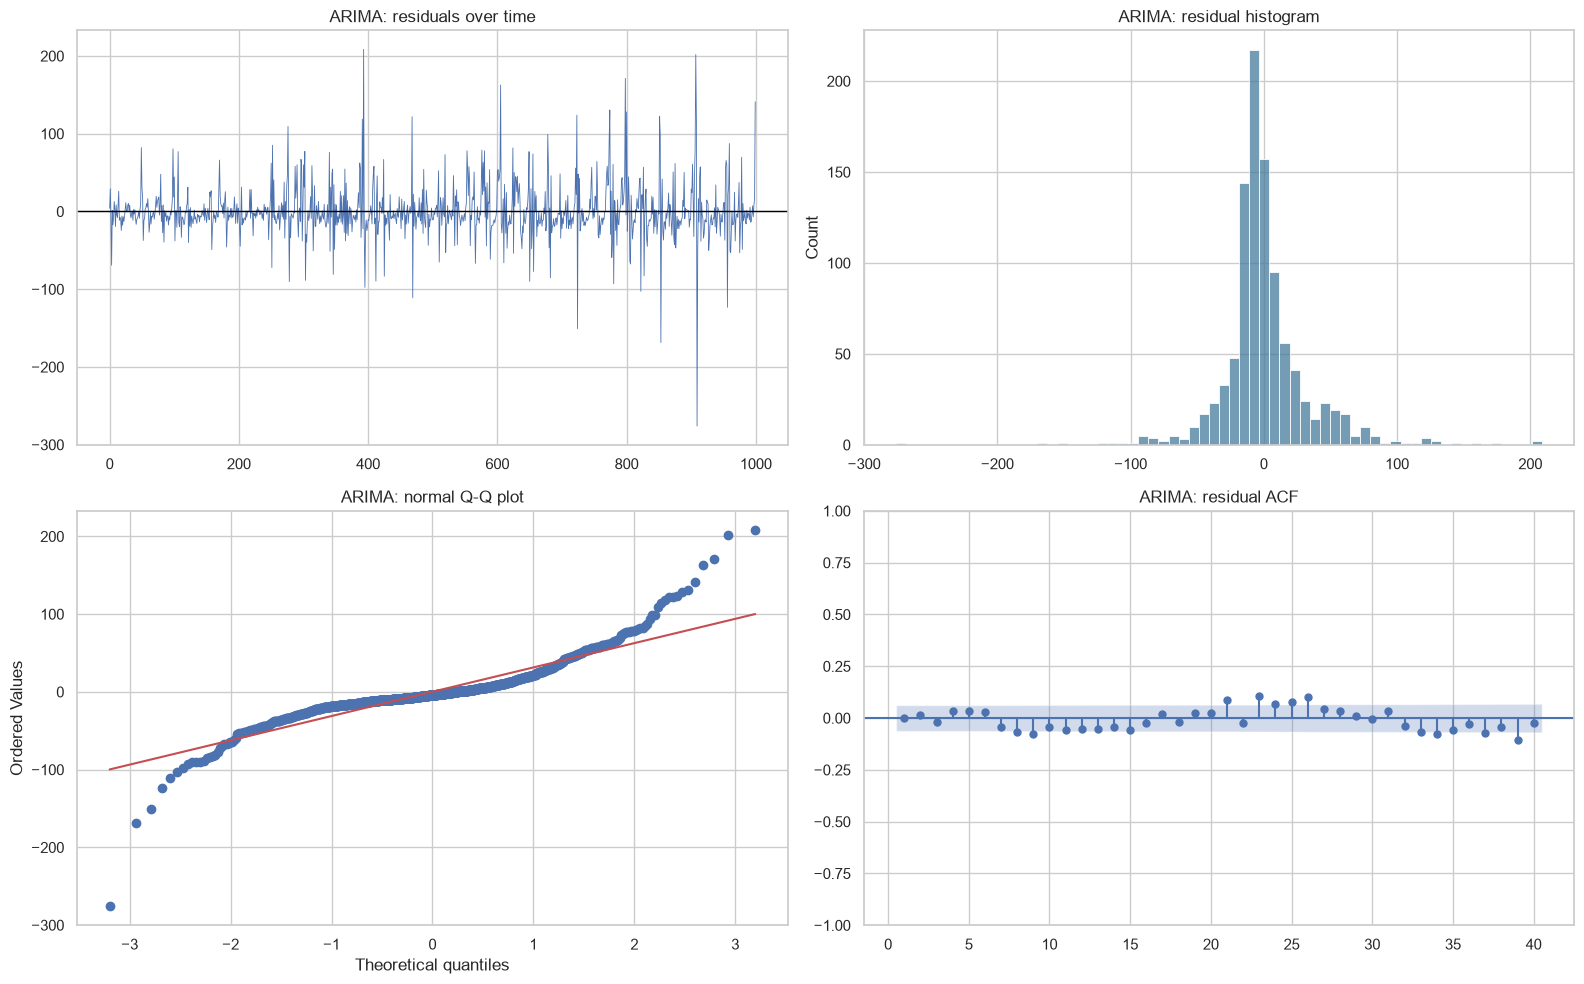

Saved: outputs\07_arima_residual_diagnostics.png
SARIMA Ljung–Box results:


,lb_stat,lb_pvalue
10,34.083394,0.000179
20,41.958038,0.002801
30,72.295317,0.000024


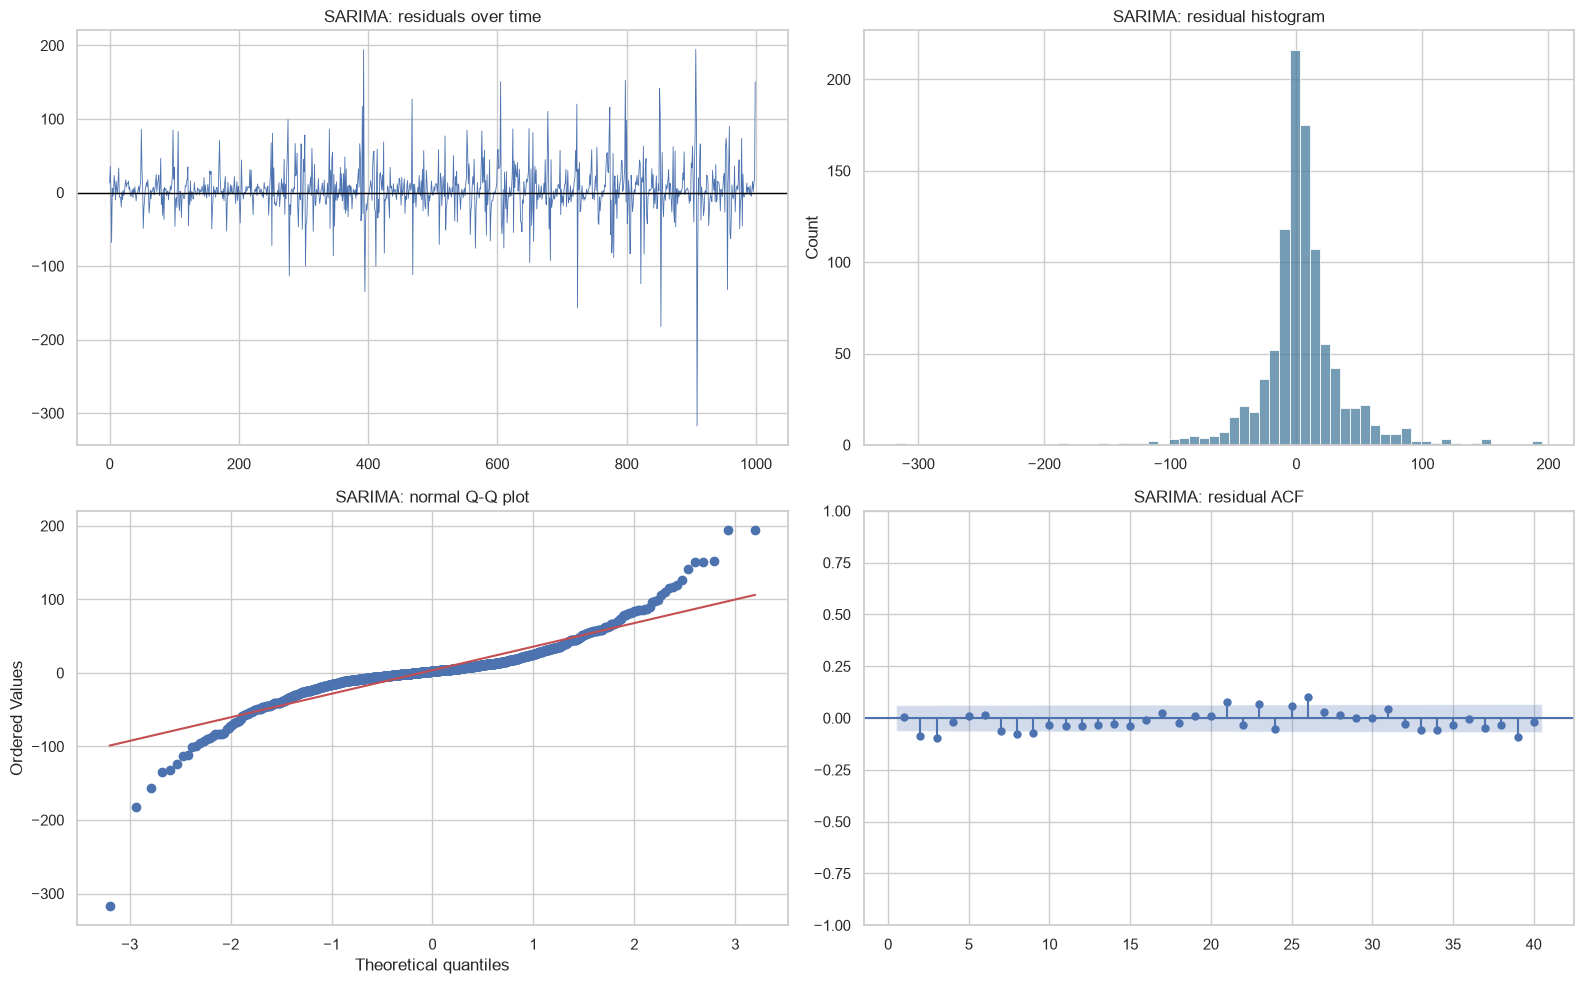

Saved: outputs\07_sarima_residual_diagnostics.png


,Model,AIC,BIC,RMSE,MAE,MAPE,Ljung-Box p
0,ARIMA,17077.984672,17099.681333,49.431136,42.020183,88.881145,0.027369
3,Seasonal Naive,NaN,NaN,56.915310,38.685686,57.665008,NaN
1,SARIMA,16958.177624,16974.412293,83.318906,68.820690,95.652067,0.002801
2,Naive,NaN,NaN,167.075263,160.810011,352.590197,NaN


In [17]:
comparison = pd.DataFrame([
    {"Model": "ARIMA", "AIC": arima_fit.aic, "BIC": arima_fit.bic, **{k: arima_metrics[k] for k in ["RMSE", "MAE", "MAPE"]}},
    {"Model": "SARIMA", "AIC": sarima_fit.aic, "BIC": sarima_fit.bic, **{k: sarima_metrics[k] for k in ["RMSE", "MAE", "MAPE"]}},
    {"Model": "Naive", "AIC": np.nan, "BIC": np.nan, **{k: baseline_rows[0][k] for k in ["RMSE", "MAE", "MAPE"]}},
    {"Model": "Seasonal Naive", "AIC": np.nan, "BIC": np.nan, **{k: baseline_rows[1][k] for k in ["RMSE", "MAE", "MAPE"]}},
])
display(comparison.sort_values("RMSE"))


def ljung_box_summary(residuals):
    residuals = pd.Series(residuals).dropna()
    lags = [lag for lag in [10, 20, 30] if lag < len(residuals)]
    if not lags:
        return pd.DataFrame(columns=["lb_stat", "lb_pvalue"])
    return acorr_ljungbox(residuals, lags=lags, return_df=True)


def diagnostic_plots(fitted, label):
    residuals = pd.Series(np.asarray(fitted.resid)).replace([np.inf, -np.inf], np.nan).dropna()
    residuals = residuals.iloc[-1000:]
    lb = ljung_box_summary(residuals)
    print(f"{label} Ljung–Box results:")
    display(lb)

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    axes[0, 0].plot(residuals.to_numpy(), linewidth=0.6)
    axes[0, 0].axhline(0, color="black", linewidth=1)
    axes[0, 0].set_title(f"{label}: residuals over time")
    sns.histplot(residuals, kde=False, ax=axes[0, 1], color="#457b9d")
    axes[0, 1].set_title(f"{label}: residual histogram")
    probplot(residuals, dist="norm", plot=axes[1, 0])
    axes[1, 0].set_title(f"{label}: normal Q-Q plot")
    plot_acf(residuals, lags=min(40, max(10, len(residuals) // 2 - 1)), ax=axes[1, 1], zero=False)
    axes[1, 1].set_title(f"{label}: residual ACF")
    save_plot(f"07_{label.lower()}_residual_diagnostics.png")
    return lb


arima_lb = diagnostic_plots(arima_fit, "ARIMA")
sarima_lb = diagnostic_plots(sarima_fit, "SARIMA")
arima_lb_p = float(arima_lb.loc[20, "lb_pvalue"]) if 20 in arima_lb.index else float(arima_lb["lb_pvalue"].iloc[-1])
sarima_lb_p = float(sarima_lb.loc[20, "lb_pvalue"]) if 20 in sarima_lb.index else float(sarima_lb["lb_pvalue"].iloc[-1])
comparison.loc[comparison["Model"].eq("ARIMA"), "Ljung-Box p"] = arima_lb_p
comparison.loc[comparison["Model"].eq("SARIMA"), "Ljung-Box p"] = sarima_lb_p
comparison.loc[comparison["Model"].isin(["Naive", "Seasonal Naive"]), "Ljung-Box p"] = np.nan
display(comparison.sort_values("RMSE"))


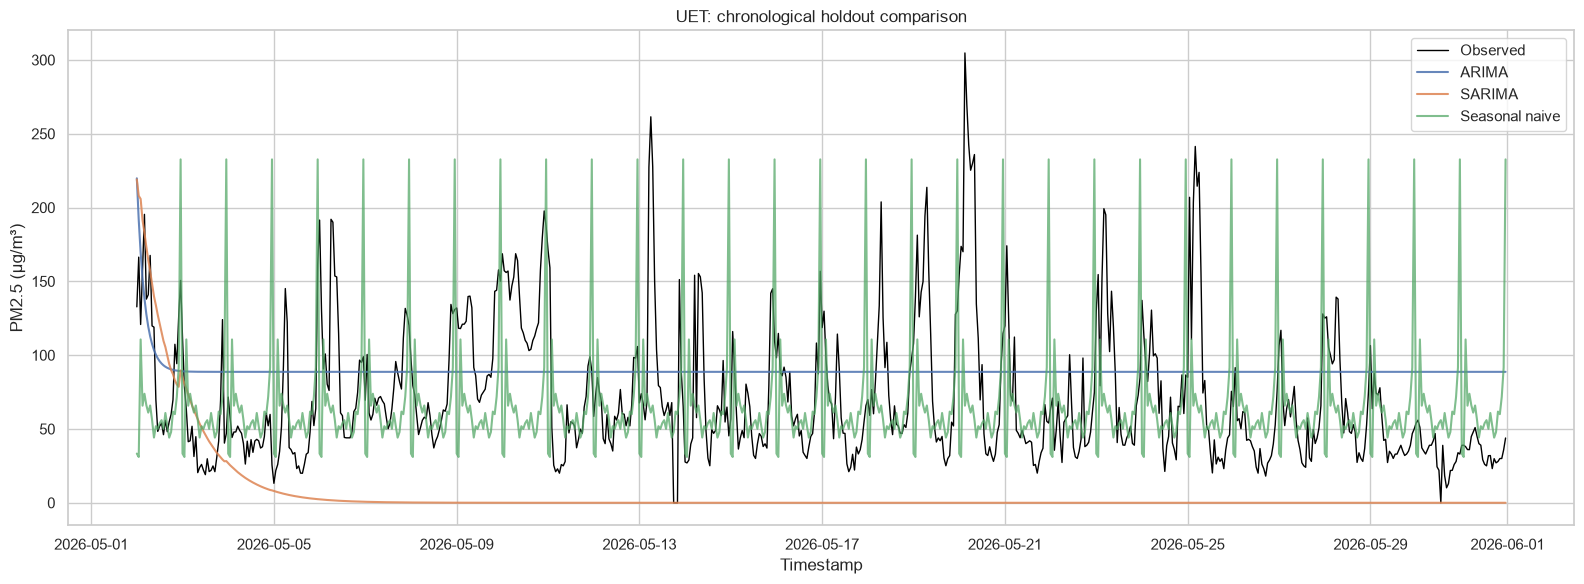

Saved: outputs\08_holdout_forecast_comparison.png


In [18]:
# Holdout forecast visual comparison in the original PM2.5 units.
plt.figure(figsize=(16, 6))
plt.plot(test.index, actual_test_original, label="Observed", color="black", linewidth=1)
plt.plot(test.index, arima_pred_original, label="ARIMA", alpha=0.85)
plt.plot(test.index, sarima_pred_original, label="SARIMA", alpha=0.85)
plt.plot(test.index, seasonal_naive_pred_original, label="Seasonal naive", alpha=0.75)
plt.title(f"{FOCUS_STATION}: chronological holdout comparison")
plt.xlabel("Timestamp")
plt.ylabel("PM2.5 (µg/m³)")
plt.legend()
save_plot("08_holdout_forecast_comparison.png")


## 9. Seven-day production forecast and saved artifacts

In [19]:

model_metric_rows = {
    "ARIMA": arima_metrics["RMSE"],
    "SARIMA": sarima_metrics["RMSE"],
    "Naive": baseline_rows[0]["RMSE"],
    "Seasonal Naive": baseline_rows[1]["RMSE"],
}
best_model_name = min(model_metric_rows, key=model_metric_rows.get)
print("Best holdout model by RMSE:", best_model_name, model_metric_rows[best_model_name])

full_series = model_values.copy()
future_index = pd.date_range(full_series.index.max() + pd.Timedelta(hours=1), periods=FORECAST_HORIZON, freq="h")

if best_model_name == "SARIMA":
    full_exog = exog_for(full_series.index)
    future_exog = exog_for(future_index)
    production_fit = SARIMAX(
        np.asarray(full_series, dtype=float),
        order=best_sarima_order,
        seasonal_order=best_sarima_seasonal_order,
        exog=None if full_exog is None else full_exog.to_numpy(),
        enforce_stationarity=False,
        enforce_invertibility=False,
        concentrate_scale=True,
    ).fit(disp=False, maxiter=5)
    production_result = production_fit.get_forecast(
        steps=FORECAST_HORIZON,
        exog=None if future_exog is None else future_exog.to_numpy(),
    )
    production_mean = np.asarray(production_result.predicted_mean, dtype=float)
    production_ci = np.asarray(production_result.conf_int(alpha=0.05), dtype=float)
    production_order = {"order": best_sarima_order, "seasonal_order": best_sarima_seasonal_order}
elif best_model_name == "ARIMA":
    full_exog = exog_for(full_series.index)
    future_exog = exog_for(future_index)
    production_fit = ARIMA(
        np.asarray(full_series, dtype=float),
        order=best_arima_order,
        exog=None if full_exog is None else full_exog.to_numpy(),
        enforce_stationarity=False,
        enforce_invertibility=False,
    ).fit()
    production_result = production_fit.get_forecast(
        steps=FORECAST_HORIZON,
        exog=None if future_exog is None else future_exog.to_numpy(),
    )
    production_mean = np.asarray(production_result.predicted_mean, dtype=float)
    production_ci = np.asarray(production_result.conf_int(alpha=0.05), dtype=float)
    production_order = {"order": best_arima_order}
else:
    if best_model_name == "Seasonal Naive":
        production_mean = seasonal_naive_forecast(full_series.to_numpy(), FORECAST_HORIZON, season=24)
    else:
        production_mean = naive_forecast(full_series.to_numpy(), FORECAST_HORIZON)
    recent_sd = float(pd.Series(full_series).diff().dropna().std())
    steps = np.arange(1, FORECAST_HORIZON + 1)
    production_ci = np.column_stack([
        production_mean - 1.96 * recent_sd * np.sqrt(steps),
        production_mean + 1.96 * recent_sd * np.sqrt(steps),
    ])
    production_fit = None
    production_order = {}

forecast_output = pd.DataFrame({
    "timestamp": future_index,
    "station": FOCUS_STATION,
    "forecast_pm25": inverse_model_transform(production_mean, transform_info),
    "lower_95": inverse_model_transform(production_ci[:, 0], transform_info),
    "upper_95": inverse_model_transform(production_ci[:, 1], transform_info),
})
forecast_output[["forecast_pm25", "lower_95", "upper_95"]] = forecast_output[
    ["forecast_pm25", "lower_95", "upper_95"]
].clip(lower=0)
forecast_output.to_csv(OUTPUT_DIR / "forecast_output.csv", index=False)
print("Saved forecast:", OUTPUT_DIR / "forecast_output.csv")
display(forecast_output.head())


Best holdout model by RMSE: ARIMA 49.43113583219937
Saved forecast: outputs\forecast_output.csv


,timestamp,station,forecast_pm25,lower_95,upper_95
0,2026-06-01 00:00:00,UET,46.160393,0.0,116.445321
1,2026-06-01 01:00:00,UET,47.518286,0.0,142.446005
2,2026-06-01 02:00:00,UET,48.593385,0.0,156.476721
3,2026-06-01 03:00:00,UET,49.444584,0.0,164.972099
4,2026-06-01 04:00:00,UET,50.118512,0.0,170.393997


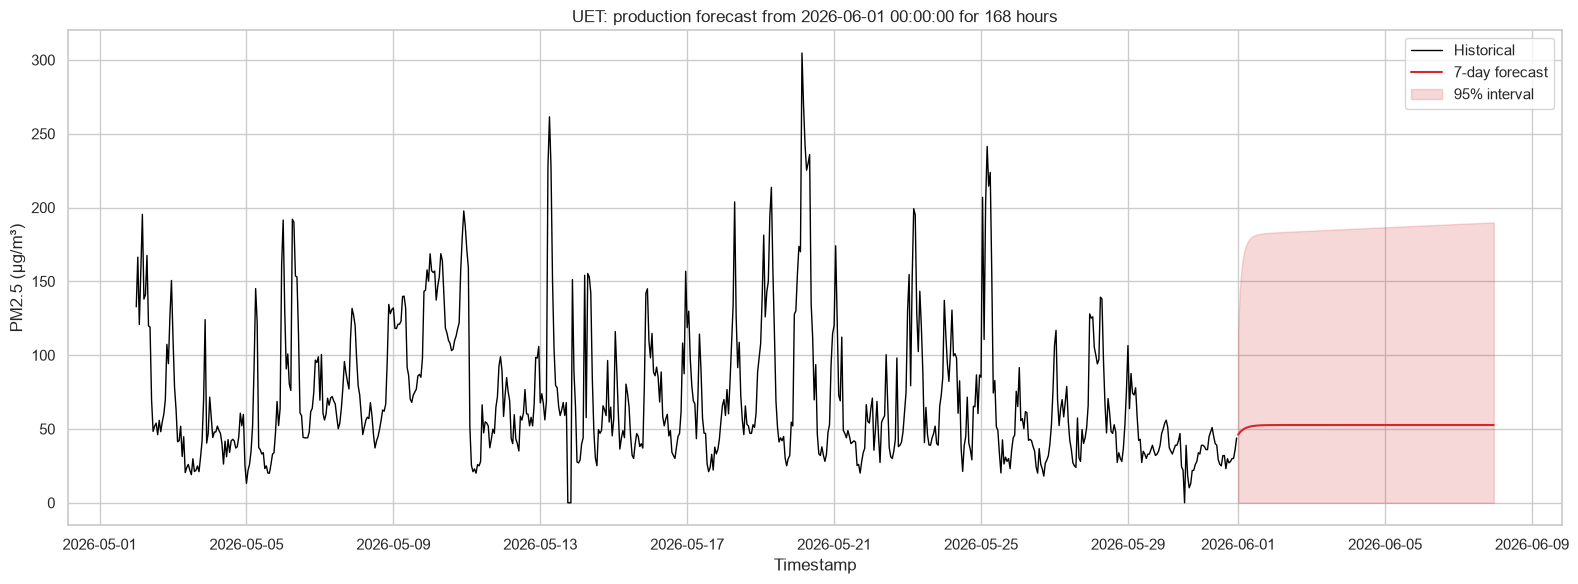

Saved: outputs\09_production_7_day_forecast.png
Saved serialized best model: outputs\best_pm25_model.joblib


In [20]:
# Plot the final seven-day forecast against the most recent 30 days.
history_original = inverse_model_transform(full_series.to_numpy(), transform_info)
plot_history = pd.Series(history_original, index=full_series.index).iloc[-30 * 24:]
plt.figure(figsize=(16, 6))
plt.plot(plot_history.index, plot_history.values, label="Historical", color="black", linewidth=1)
plt.plot(forecast_output["timestamp"], forecast_output["forecast_pm25"], label="7-day forecast", color="#d62828")
plt.fill_between(
    forecast_output["timestamp"],
    forecast_output["lower_95"],
    forecast_output["upper_95"],
    color="#d62828",
    alpha=0.18,
    label="95% interval",
)
plt.title(f"{FOCUS_STATION}: production forecast from {future_index.min()} for 168 hours")
plt.xlabel("Timestamp")
plt.ylabel("PM2.5 (µg/m³)")
plt.legend()
save_plot("09_production_7_day_forecast.png")

best_model_payload = {
    "station": FOCUS_STATION,
    "model_name": best_model_name,
    "model": production_fit,
    "orders": production_order,
    "transform_info": transform_info,
    "use_calendar_exogenous": USE_CALENDAR_EXOGENOUS,
    "training_start": str(full_series.index.min()),
    "training_end": str(full_series.index.max()),
}
model_path = OUTPUT_DIR / "best_pm25_model.joblib"
joblib.dump(best_model_payload, model_path)
print("Saved serialized best model:", model_path)


## 10. Brief generalization check on other stations

In [21]:
def secondary_sarima_evaluation(station, order, seasonal_order):
    series = modeling_series(station)
    if len(series) < 500:
        print(f"WARNING: skipping {station}; only {len(series)} valid points.")
        return None
    # Keep the generalization check light-weight; the primary station receives
    # the full modeling treatment above.
    series = series.iloc[-500:]
    transformed, station_transform = transform_for_model(series)
    station_train, station_test = chronological_split(transformed)
    try:
        fitted, pred = fit_sarima(order, seasonal_order, station_train, station_test)
        actual = inverse_model_transform(station_test.to_numpy(), station_transform)
        predicted = inverse_model_transform(pred.to_numpy(), station_transform)
        metrics = forecast_metrics(actual, predicted)
        return {
            "Station": station,
            "n": len(series),
            "RMSE": metrics["RMSE"],
            "MAE": metrics["MAE"],
            "MAPE": metrics["MAPE"],
            "AIC": fitted.aic,
            "BIC": fitted.bic,
        }
    except Exception as exc:
        print(f"WARNING: SARIMA failed for {station}: {exc}")
        return None


secondary_candidates = [
    station for station in ["LWMC", "Sheikhupura", "Gujranwala", "Shahdara", "Kahna"]
    if station in available_stations and station != FOCUS_STATION
][:2]
if "production_fit" in globals():
    del production_fit
if "best_model_payload" in globals():
    best_model_payload["model"] = None
gc.collect()
secondary_rows = []
for station in secondary_candidates:
    row = secondary_sarima_evaluation(station, best_sarima_order, best_sarima_seasonal_order)
    if row is not None:
        secondary_rows.append(row)
secondary_results = pd.DataFrame(secondary_rows)
display(secondary_results if not secondary_results.empty else pd.DataFrame(
    {"message": ["No secondary station met the minimum data requirement."]}
))


LWMC: using the latest 2400 of 8251 valid hourly observations for computationally stable ARIMA/SARIMA fitting; EDA still uses the complete cleaned dataset.
Variance-growth diagnostic: 0.881
Box-Cox applied: False lambda: None shift: 1e-06
Sheikhupura: using the latest 2400 of 8553 valid hourly observations for computationally stable ARIMA/SARIMA fitting; EDA still uses the complete cleaned dataset.
Variance-growth diagnostic: 0.9917
Box-Cox applied: False lambda: None shift: 1e-06


,Station,n,RMSE,MAE,MAPE,AIC,BIC
0,LWMC,500,108.919174,79.896303,96.426408,744.495101,751.447566
1,Sheikhupura,500,64.922908,55.436262,96.642628,689.748384,696.700849
